강의자료 05에서, CIFAR-10분류기를 구현하고, 성능을 시각화(Epoch-Accuracy 그래프와 혼동행렬 포함)하는 코드를 작성하여 제출하세요.

위 범위의 코드의 실습을 진행해 ipynb(쥬피터 노트북 또는 코랩 사용) 형식으로 제출하기 바랍니다.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

CIFAR-10 데이터셋 로드 중...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.5632443].


CIFAR-10 데이터셋 로드 완료)
훈련 데이터: 50000 개
테스트 데이터: 10000 개

CIFAR-10 샘플 이미지들:


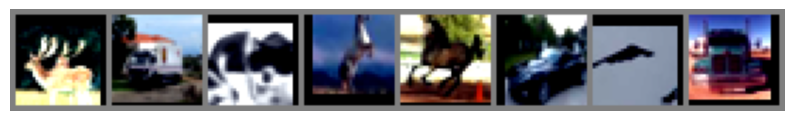

클래스: deer truck cat horse horse car plane truck

이미지 크기: torch.Size([3, 32, 32])
배치 크기: 128
클래스 개수: 10


In [ ]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
#정규화
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
#데이터셋 불러오기
print("CIFAR-10 데이터셋 로드 중...")
try:
    train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
    #데이터로더 생성
    train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True, num_workers=0)
    test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=100, shuffle=False, num_workers=0)
    print("CIFAR-10 데이터셋 로드 완료)")
    print(f"훈련 데이터: {len(train_dataset)} 개")
    print(f"테스트 데이터: {len(test_dataset)} 개")
except Exception as e:
    print(f"데이터셋 로드 중 오류 발생: {e}")
    print("인터넷 연결을 확인하거나 데이터셋 경로를 확인해주세요.")

#클래스 이름
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse','ship', 'truck')

#이미지 시각화 함수
def imshow(img):
    img = img / 2 + 0.5 # 정규화 해제
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

#샘플 이미지 시각화
try:
    dataiter = iter(train_loader)
    images, labels = next(dataiter)
    print("\nCIFAR-10 샘플 이미지들:")
    imshow(torchvision.utils.make_grid(images[:8]))
    print('클래스: '+' '.join([classes[labels[j]] for j in range(8)]))
    #CIFAR-10 데이터셋 정보 출력
    print(f"\n이미지 크기: {images [0].shape}")
    print(f"배치 크기: {images.shape[0]}")
    print(f"클래스 개수: {len (classes)}")

except Exception as e:
    print(f"이미지 시각화 중 오류 발생: {e}")

In [ ]:
import torch.nn as nn

#CIFAR-10용 CNN 모델 정의
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()
        #특성 추출 레이어
        self.features = nn.Sequential(
            #첫 번째 합성곱 블록
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), 
            nn.ReLU(inplace=True), 
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),

            #두 번째 합성곱 블록
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25),
        
            #세 번째 합성곱 블록
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25)
        )

        #분류 레이어
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
#모델, 손실 함수, 최적화 초기화
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
cifar_model = CIFAR10_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cifar_model.parameters(), lr=0.001)
print("CIFAR-10 CNN 모델:")
print(cifar_model)

#모델 파라미터 수
cifar_params = sum(p.numel() for p in cifar_model.parameters())
print(f"\nCIFAR-10 CNN 파라미터 수: {cifar_params}")
print(f"사용 디바이스: {device}")

#간단한 학습 함수 정의
def train_epoch(model, train_loader, criterion, optimizer, device):
    #한 에포크 학습
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (inputs, labels) in enumerate(train_loader):
        if i == 10: # 빠른 데모를 위해 10 배치만 학습
            break
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if i % 5 == 4:
            print(f'배치 {i+1}, 손실: {running_loss/(i+1):.3f}, 정확도: {100.*correct/total:.2f}')

    return running_loss/min(i+1, 10), 100.*correct/total

#평가 함수 정의
def evaluate_model(model, test_loader, criterion, device):
    #모델 평가
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            if 1 > 5: # 빠른 데모를 위해 5 배치만 평가
                break
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return test_loss/(i+1), 100.*correct/total

# 간단한 학습 실행
try:
    if 'train_loader' in locals():
        print("\n= 모델 학습 시작 (데모) =")
        for epoch in range(2): # 2에포크만 실행
            print(f"\n에포크 {epoch+1}/2:")
            train_loss, train_acc = train_epoch(cifar_model, train_loader, criterion, optimizer, device)
        print("\n=== 모델 평가 ===")
        test_loss, test_acc = evaluate_model(cifar_model, test_loader, criterion, device)
        print(f"테스트 손실: {test_loss:.3f}, 테스트 정확도: {test_acc:.2f}")
        
    else:
        print("데이터로더가 준비되지 않아 학습을 건너뜁니다.")
except Exception as e:
    print(f"학습 중 오류 발생: {e}")

CIFAR-10 CNN 모델:
CIFAR10_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, pa

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.5632443].


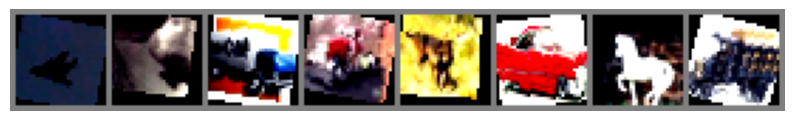

plane birdtrucktruck deer  carhorsetruck


In [4]:
#이미지 시각화 함수 정의
def imshow(img):
    img = img / 2 + 0.5 # 정규화 해제
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

#CIFAR-10 클래스 이름
classes = ('plane', 'car', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck')

#더 다양한 데이터 증강 기법 적용
transform_train_augmented = transforms.Compose([
    transforms. RandomCrop (32, padding=4), # 랜덤 크롭
    transforms. RandomHorizontalFlip(), # 수평 뒤집기
    transforms. RandomRotation (15), # 랜덤 회전(+-15)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    
    #색상 변화
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# 증강된 데이터셋 불러오기
train_dataset_augmented = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train_augmented)

train_loader_augmented = torch.utils.data.DataLoader(train_dataset_augmented, batch_size=128, shuffle=True, num_workers=2)

#증강된 샘플 이미지 시각화
dataiter = iter(train_loader_augmented)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]))
print(''.join('%5s' % classes[labels[j]] for j in range(8)))

In [ ]:
#디바이스 설정
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

def train_epoch(model, train_loader, criterion, optimizer, device):
    #한 에포크 학습 - 수정된 버전
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for i, (inputs, labels) in enumerate(train_loader):
        if i == 10: # 빠른 데모를 위해 10 배치만 학습
            break
    #입력 데이터와 라벨을 같은 디바이스로 이동
    inputs, labels = inputs.to(device), labels.to(device)
    #기울기 초기화
    optimizer.zero_grad()

    #순전파
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    
    #역전파
    loss.backward()
    optimizer.step()
    
    #통계 계산
    running_loss += loss.item()
    _, predicted = outputs.max(1)
    total += labels.size(0)
    correct += predicted.eq(labels).sum().item()

    if i% 5 == 4:
        print(f'배치 {i+1}, 손실: {running_loss/(i+1):.3f}, 정확도: {100.*correct/total:.2f}%')
    return running_loss/min(i+1, 10), 100.*correct/total

def evaluate_model(model, test_loader, criterion, device):
    #모델 평가 - 수정된 버전
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            if i == 5: # 빠른 데모를 위해 5 배치만 평가
                break

        # 입력 데이터와 라벨을 같은 디바이스로 이동
        inputs, labels = inputs.to(device), labels.to(device)
        
        #순전파
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        #통계 계산
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return test_loss/(i+1), 100.*correct/total

# 시각화를 위한 기록용 리스트 (전역 설정)
train_acc_list = []
test_acc_list = []

# 더 안전한 학습 함수(에러 처리 포함)
def safe_train_model(model,train_loader,test_loader,criterion,optimizer,device,epochs=2):
    try:
        print(f"모델 디바이스: {next(model.parameters()).device}")
        print(f"타겟 디바이스: {device}")
    
        #모델이 올바른 디바이스에 있는지 확인
        model = model.to(device)
        for epoch in range(epochs):
            print(f"\n에포크 {epoch+1}/{epochs}:")
        
            #학습
            train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
            print(f"학습 완료 - 손실: {train_loss:.3f}, 정확도: {train_acc:.2f}")
        
            # 평가(선택적)
            if test_loader is not None:
                test_loss, test_acc = evaluate_model(model, test_loader, criterion, device)
            print(f"평가 완료 - 손실: {test_loss:.3f}, 정확도: {test_acc:.2f}")
            print("학습 완료!")
            
            train_acc_list.append(train_acc)
            test_acc_list.append(test_acc)

    except Exception as e:
        print(f"학습 중 오류 발생: {e}")
        print("오류 해결 방법:")
        print("1. 모델과 데이터가 같은 디바이스에 있는지 확인")
        print("2. 메모리 부족시 배치 크기 줄이기")
        print("3. CUDA 사용 가능한지 확인")

#실제 학습 실행 부분
print("\n=== 안전한 모델 학습 시작")

# 모델이 정의되어 있는지 확인
try:
    #이전 실습에서 정의된 모델들 중 하나 사용
    if 'cifar model' in locals():
        model = cifar_model
        print("CIFAR-10 CNN 모델 사용")
    elif 'simple_cnn' in locals():
        model = simple_cnn
        print("Simple CNN 모델 사용")
    else:
        #간단한 모델 직접 정의
        class SimpleCNN(nn.Module):
            def __init__(self):
                super(SimpleCNN, self).__init__()
                self.features = nn.Sequential(
                    nn.Conv2d(3, 32, 3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(2),
                    nn.Conv2d(32, 64, 3, padding=1),
                    nn.ReLU(),
                    nn.MaxPool2d(2),
                    nn.Conv2d(64, 128, 3, padding=1),
                    nn.ReLU(),
                    nn.AdaptiveAvgPool2d((1, 1))
                )
                self.classifier = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(128, 10)
                )
            def forward(self, x):
                x = self.features(x)
                x = self.classifier(x)
                return x
        model = SimpleCNN()
        print("새로운 Simple CNN 모델 생성")

    #모델을 디바이스로 이동
    model = model.to(device)

    #손실 함수와 옵티마이저 설정
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # 데이터로더 확인(locals와 globals 모두 확인)
    train_loader = None
    test_loader = None

#가능한 train_loader 변수명들을 순서대로 확인
    possible_train_loaders = ['train_loader_augmented',
                              'advanced_aug_loader',
                              'basic_aug_loader',
                              'train_loader',
                              'basic_loader']
    possible_test_loaders = [
        'test_loader'
    ]
    # globals()와 locals() 모두에서 확인
    all_vars = {**globals(), **locals()}

    #train_loader 찾기
    for loader_name in possible_train_loaders:
        if loader_name in all_vars:
            train_loader = all_vars [loader_name]
            print(f"{loader_name} 발견하여 사용")
            break

    # test_loader
    for loader_name in possible_test_loaders:
        if loader_name in all_vars:
            test_loader = all_vars [loader_name]
            print(f"{loader_name} 발견하여 사용")
            break

    #데이터로더가 없으면 직접 생성
    if train_loader is None:
        print("X 기존 데이터로더를 찾을 수 없습니다.")
        print("CIFAR-10 데이터로더를 새로 생성합니다...")
    try:
        import torchvision
        import torchvision.transforms as transforms
        
        #기본 transform 정의
        transform_train = transforms.Compose([transforms. RandomCrop(32, padding=4), transforms. RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

        transform_test = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))])

        #데이터셋 로드
        train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
        test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

        #데이터로더 생성
        train_loader = torch.utils.data.DataLoader(
            train_dataset, batch_size=64, shuffle=True, num_workers=0)
        #batch_size 줄임
        test_loader = torch.utils.data.DataLoader(
            test_dataset, batch_size=64, shuffle=False, num_workers=0)
        
        #batch_size 줄임
        print(" CIFAR-10 데이터로더 생성 완료!")
        print(f"훈련 데이터: {len (train_dataset)}개")
        print(f"테스트 데이터: {len (test_dataset)} 개")

    except Exception as e:
        print(f"데이터로더 생성 실패: {e}")
        print(f"더미 데이터로 순전파 테스트만 실행합니다.")
        
        #더미 데이터로 테스트
        dummy_data = torch.randn(4, 3, 32, 32).to(device)
        dummy_labels = torch.randint(0, 10, (4,)).to(device)
        print("더미 데이터로 순전파 테스트:")
        model.eval()

        with torch.no_grad():
            outputs = model(dummy_data)
        
        print(f"출력 크기: {outputs.shape}")
        print("순전파 테스트 성공!")
        train_loader = None # 학습 방지

    #안전한 학습 실행(데이터로더가 있는 경우만)
    if train_loader is not None:
        safe_train_model(model, train_loader, test_loader, criterion, optimizer, device, epochs=100)

    else:
        print("학습용 데이터로더가 없어서 학습을 건너뜁니다.")

except Exception as e:
    print(f"모델 설정 중 오류: {e}")
    print("\n디버깅 정보:")
    print(f"CUDA 사용 가능: {torch.cuda.is_available()}")
    
    if torch.cuda.is_available():
        print(f"CUDA 디바이스 수: {torch.cuda.device_count()}")
        print(f"현재 CUDA 디바이스: {torch.cuda.current_device()}")

사용 디바이스: cpu

=== 안전한 모델 학습 시작
새로운 Simple CNN 모델 생성
train_loader_augmented 발견하여 사용
test_loader 발견하여 사용
 CIFAR-10 데이터로더 생성 완료!
훈련 데이터: 50000개
테스트 데이터: 10000 개
모델 디바이스: cpu
타겟 디바이스: cpu

에포크 1/100:
학습 완료 -손실: 0.230, 정확도: 9.38
평가 완료 -손실: 0.384, 정확도:  7.81
학습 완료!

에포크 2/100:
학습 완료 -손실: 0.230, 정확도: 7.81
평가 완료 -손실: 0.384, 정확도:  7.81
학습 완료!

에포크 3/100:
학습 완료 -손실: 0.233, 정확도: 6.25
평가 완료 -손실: 0.383, 정확도:  7.81
학습 완료!

에포크 4/100:
학습 완료 -손실: 0.230, 정확도: 12.50
평가 완료 -손실: 0.382, 정확도:  7.81
학습 완료!

에포크 5/100:
학습 완료 -손실: 0.227, 정확도: 18.75
평가 완료 -손실: 0.382, 정확도:  9.38
학습 완료!

에포크 6/100:
학습 완료 -손실: 0.232, 정확도: 4.69
평가 완료 -손실: 0.381, 정확도:  7.81
학습 완료!

에포크 7/100:
학습 완료 -손실: 0.228, 정확도: 14.06
평가 완료 -손실: 0.381, 정확도:  9.38
학습 완료!

에포크 8/100:
학습 완료 -손실: 0.226, 정확도: 14.06
평가 완료 -손실: 0.380, 정확도:  12.50
학습 완료!

에포크 9/100:
학습 완료 -손실: 0.226, 정확도: 26.56
평가 완료 -손실: 0.379, 정확도:  10.94
학습 완료!

에포크 10/100:
학습 완료 -손실: 0.226, 정확도: 18.75
평가 완료 -손실: 0.379, 정확도:  10.94
학습 완료!

에포크 11/100:
학습 완료 -손실: 0.225, 정확도: 21.88
평가 완

train_acc_list: [9.375, 7.8125, 6.25, 12.5, 18.75, 4.6875, 14.0625, 14.0625, 26.5625, 18.75, 21.875, 20.3125, 20.3125, 15.625, 14.0625, 12.5, 18.75, 18.75, 17.1875, 18.75, 29.6875, 20.3125, 20.3125, 31.25, 23.4375, 17.1875, 17.1875, 26.5625, 17.1875, 26.5625, 12.5, 20.3125, 29.6875, 17.1875, 15.625, 25.0, 18.75, 23.4375, 20.3125, 18.75, 18.75, 23.4375, 23.4375, 20.3125, 18.75, 20.3125, 29.6875, 29.6875, 20.3125, 25.0, 18.75, 18.75, 28.125, 21.875, 20.3125, 26.5625, 18.75, 29.6875, 26.5625, 21.875, 12.5, 20.3125, 29.6875, 17.1875, 28.125, 15.625, 26.5625, 17.1875, 28.125, 31.25, 31.25, 14.0625, 34.375, 17.1875, 12.5, 34.375, 25.0, 34.375, 31.25, 26.5625, 14.0625, 17.1875, 15.625, 25.0, 26.5625, 21.875, 21.875, 25.0, 21.875, 35.9375, 34.375, 32.8125, 28.125, 12.5, 29.6875, 23.4375, 25.0, 18.75, 21.875, 25.0]
test_acc_list: [7.8125, 7.8125, 7.8125, 7.8125, 9.375, 7.8125, 9.375, 12.5, 10.9375, 10.9375, 10.9375, 9.375, 10.9375, 14.0625, 15.625, 15.625, 18.75, 20.3125, 21.875, 20.3125, 21.87

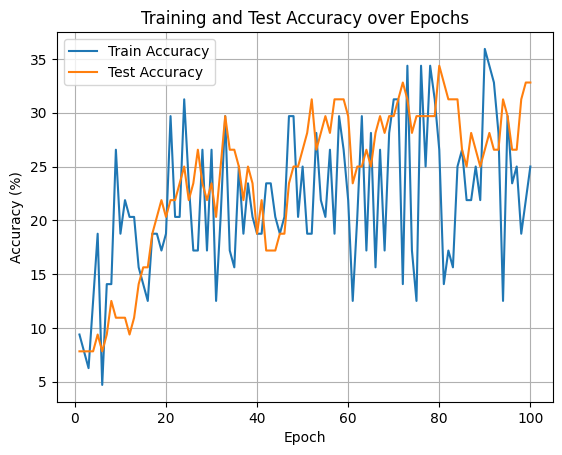

In [6]:
print("train_acc_list:", train_acc_list)
print("test_acc_list:", test_acc_list)

plt.figure()


plt.plot(range(1, len(train_acc_list) + 1), train_acc_list, label='Train Accuracy')
    
if len(test_acc_list) == len(train_acc_list):
    plt.plot(range(1, len(test_acc_list) + 1), test_acc_list, label='Test Accuracy')
else:
    print("test_acc_list가 비어있음!")

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Test Accuracy over Epochs')
plt.legend()
plt.grid()

plt.show()

데이터 수: 10000


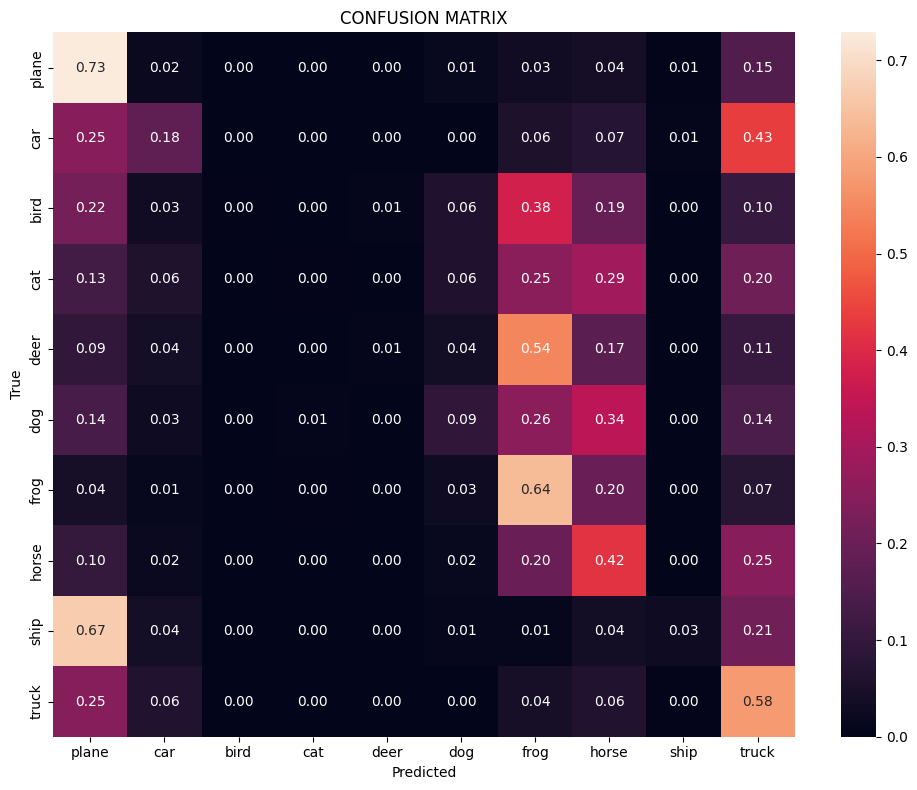

In [ ]:
# 혼동 행렬
def plot_confusion_matrix(model, test_loader, device):
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    print("데이터 수:", len(all_labels))

    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # 클래스 레이블 설정
    classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=classes, yticklabels=classes)
    plt.title("CONFUSION MATRIX")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(model, test_loader, device)